<a href="https://colab.research.google.com/github/juanmorales2993/Ayudantias/blob/main/Ayudantia_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ayudantía 11: Causal Forest y Double Machine Learning**

**Curso:** Aplicaciones de Machine Learning en Economía

**Ayudantes:**
- Maykol Medrano — mmedrano2@uc.cl
- Pablo Acevedo — jbvillagra@uc.cl

---

Netflix decide a qué usuarios mostrarle un descuento. Amazon elige a quién enviar una promoción. Un gobierno define qué hogares priorizar en un programa social. El problema en todos los casos es el mismo: el efecto promedio del tratamiento esconde quién responde y quién no. Aplicar la misma intervención a todos desperdicia recursos en quienes apenas reaccionan.

**Causal Forest + DML** resuelve eso: en lugar de un ATE para todos, estima un efecto por perfil de individuo — el CATE — y con eso permite focalizar. Hoy lo aplicamos a datos reales de pensiones en EE.UU.

---

## **Framework**

OLS estima $\tau$ bajo tres supuestos. Los primeros dos son restrictivos y los vamos a relajar uno por uno:

| Supuesto | OLS asume | ¿Lo relajamos? |
|:---|:---|:---|
| (1) Ignorabilidad | $Y(0),Y(1) \perp T \mid X$ | No — lo mantenemos (es el supuesto causal) |
| (2) Linealidad | $X$ entra linealmente en $Y$ | **Sí → DML** |
| (3) Efecto constante | $\tau$ igual para todos | **Sí → Causal Forest** |

---

**Relajar (2): Partial Linear Model + DML**

En lugar de asumir linealidad, modelamos $X$ con cualquier función:

$$Y_i = \tau \cdot T_i + m(X_i) + \varepsilon_i$$

Robinson (1988) muestra que se puede aislar $\tau$ sin especificar $m(\cdot)$. Calculamos residuos $\tilde{Y} = Y - \hat{m}(X)$ y $\tilde{T} = T - \hat{e}(X)$, y estimamos $\tau$ regresando residuo sobre residuo — libre de la confusión de $X$.

---

**Relajar (3): de ATE a CATE**

Una opción obvia es dividir la muestra en subgrupos y estimar $\tau$ por separado en cada uno. El problema: los subgrupos se eligen *antes* de ver los datos o *mirando* los datos — eso es p-hacking. Además, con 8 covariables no escala.

La solución es estimar $\tau$ **localmente** de forma data-driven:

$$\tau(x) = E[Y(1) - Y(0) \mid X = x]$$

**Causal Forest** combina Random Forest + Robinson: los árboles no minimizan el error de predicción de $Y$, sino que maximizan la heterogeneidad del efecto entre ramas:

$$\Delta(\ell_L, \ell_R) = \frac{n_L \cdot n_R}{n_L + n_R}(\hat{\tau}_L - \hat{\tau}_R)^2$$

Dentro de cada vecindad definida por los pesos $\alpha_i(x)$, estima el CATE vía residuo sobre residuo:

$$\hat{\tau}(x) = \frac{\sum_i \alpha_i(x)\,\tilde{T}_i\,\tilde{Y}_i}{\sum_i \alpha_i(x)\,\tilde{T}_i^2}$$

### **Contenidos**

| | Pregunta que responde | Herramienta |
|---|---|---|
| **Framework** | ¿Por qué OLS no basta? ¿Cómo relajamos sus supuestos? | PLM + DML + Causal Forest |
| **Paso 1** | ¿Cómo son los datos del estudio? | `pd.read_stata()` — SIPP 1991 |
| **Paso 2** | ¿Aumenta la elegibilidad el ahorro en promedio? | OLS — ATE |
| **Paso 3** | ¿Cómo limpiamos la confusión entre perfil e ingreso? | DML / Robinson (1988) |
| **Paso 4** | ¿Cómo funciona el Causal Forest? | Athey, Tibshirani & Wager (2019) |
| **Paso 5** | Código | `CausalForestDML` — EconML |
| **Paso 6** | ¿Quién se beneficia más de la elegibilidad? | Resultados + CATE |
| **Paso 7** | ¿A qué tipo de hogar priorizar? | Curva de targeting + Policy Tree |

In [ ]:
!pip install econml==0.16.0 "scikit-learn==1.6.1" -q  # descomentar si hay errores de compatibilidad

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression
from econml.dml import CausalForestDML

print('Librerías cargadas OK')

Librerías cargadas OK


---

## **Paso 1 — Los datos: Survey of Income and Program Participation (SIPP 1991)**

Poterba, Venti & Wise (1995) se preguntan: **¿tener acceso a un 401(k) hace que los hogares ahorren más en total, o simplemente mueven plata que ya tenían en otra cuenta?** Para responderlo construyen una muestra de 9,915 hogares de la encuesta SIPP. La variable de tratamiento es `e401` — si el **empleador** ofrece el plan — no `p401` (participación voluntaria del empleado). Esa distinción es clave: la elegibilidad la decide la firma por razones de industria y tamaño, no el individuo, lo que permite estimar un efecto causal.

- **T** = `e401` — elegibilidad al 401(k) asignada por el empleador
- **Y** = `net_tfa` — activos financieros netos (cuentas de ahorro, bonos, acciones; excluye vivienda y pensiones formales)
- **X** = `age`, `inc`, `fsize`, `educ`, `pira`, `hown`, `marr`, `twoearn`

In [ ]:
# Dataset original de Chernozhukov et al. (2018) / Poterba, Venti & Wise (1994)
# Fuente: VC2015/DMLonGitHub (GitHub del paper DML)
url  = 'https://github.com/VC2015/DMLonGitHub/raw/master/sipp1991.dta'
data = pd.read_stata(url)

# Variables del experimento
Y_raw = data['net_tfa'].values   # Activos financieros netos (USD)
T     = data['e401'].values      # Elegibilidad 401(k) — asignada por el empleador

feature_cols = ['age', 'inc', 'fsize', 'educ', 'pira', 'hown', 'marr', 'twoearn']
X = data[feature_cols].copy()

print(f'Observaciones:  {len(data):,}')
print(f'Elegibles (T=1): {T.mean()*100:.1f}%   No elegibles (T=0): {(1-T).mean()*100:.1f}%')
print(f'\nActivos netos (Y_raw):')
print(f'  Mediana:   ${np.median(Y_raw):>10,.0f}')
print(f'  Media:     ${Y_raw.mean():>10,.0f}')
print(f'  p99:       ${np.percentile(Y_raw, 99):>10,.0f}')
print(f'  Máximo:    ${Y_raw.max():>10,.0f}')

# Winsorización al 1% superior
p99 = np.percentile(Y_raw, 99)
Y   = np.clip(Y_raw, None, p99)
print(f'\nY winsorizado al p99 (${p99:,.0f}): {(Y_raw > p99).sum()} obs truncadas ({(Y_raw > p99).mean()*100:.1f}%)')

Observaciones:  9,915
Elegibles (T=1): 37.1%   No elegibles (T=0): 62.9%

Activos netos (Y_raw):
  Mediana:   $     1,499
  Media:     $    18,052
  p99:       $   219,922
  Máximo:    $ 1,536,798

Y winsorizado al p99 ($219,922): 100 obs truncadas (1.0%)


In [ ]:
display(data[feature_cols + ['e401', 'net_tfa']].head())

,age,inc,fsize,educ,pira,hown,marr,twoearn,e401,net_tfa
0,47,6765.0,2,8,0,1,0,0,0,0.0
1,36,28452.0,1,16,0,1,0,0,0,1015.0
2,37,3300.0,6,12,0,0,0,0,0,-2000.0
3,58,52590.0,2,16,0,1,1,1,0,15000.0
4,32,21804.0,1,11,0,1,0,0,0,0.0


---

## **Paso 2 — ¿Aumenta la elegibilidad el ahorro? (OLS)**

Poterba, Venti & Wise (1995) estiman la siguiente ecuación para responder la pregunta:

$$Y_i = \alpha + \tau \cdot T_i + X_i'\beta + \varepsilon_i$$

donde $\tau$ es el **ATE** — cuánto aumentan los activos financieros netos en promedio por ser elegible. Lo estimamos y luego preguntamos: ¿es suficiente con un solo número?

In [ ]:
# ATE naive: diferencia de medias
ate_naive = Y[T == 1].mean() - Y[T == 0].mean()

# OLS con controles — cast a float64 para evitar pérdida de precisión con datos Stata (float32)
Xols    = np.column_stack([T, X.values]).astype(np.float64)
ols     = LinearRegression().fit(Xols, Y.astype(np.float64))



print(f'ATE naive (diferencia de medias): ${ate_naive:>10,.0f}')
print(f'ATE OLS (con controles):          ${ate_ols:>10,.0f}')
print()
print('OLS responde: sí, la elegibilidad aumenta el ahorro. Pero no puede responder: ¿para quién más?')

ATE naive (diferencia de medias): $    17,785
ATE OLS (con controles):          $     7,073

OLS responde: sí, la elegibilidad aumenta el ahorro. Pero no puede responder: ¿para quién más?


OLS impone los supuestos (2) y (3) del Framework — linealidad y efecto constante. Los pasos siguientes los relajan: **Paso 3** elimina (2) con DML, **Paso 4-5** eliminan (3) con Causal Forest.

---

## **Paso 3 — Double Machine Learning: limpiar la confusión**

El ingreso (`inc`) afecta tanto qué empleador contrata (→ T) como cuánto se ahorra (→ Y). Si metemos los datos crudos, el modelo confunde correlación con causalidad.

**DML entrena dos modelos independientes:**
- `model_y` → predice $E[Y \mid X]$, calcula residuo $\tilde{Y} = Y - \hat{m}(X)$
- `model_t` → predice $E[T \mid X]$, calcula residuo $\tilde{T} = T - \hat{e}(X)$

El Causal Forest solo ve $\tilde{Y}$ y $\tilde{T}$ — datos ya limpios de la influencia de X.

> **Cross-fitting (interno en EconML):** los residuos se calculan en datos que el modelo no vio (K-Fold), previniendo data leakage. `cf.fit(Y, T, X=X)` hace esto automáticamente.

> **Ignorabilidad:** DML no elimina confusores que no estén en X. El supuesto $Y(0), Y(1) \perp T \mid X$ es lo que hace el trabajo causal — no es automático, hay que defenderlo.

---

## **Paso 4 — Causal Forest: tres ideas clave**

**Splitting:** los árboles no minimizan el error de predicción de Y — dividen las ramas maximizando la **diferencia de efecto** entre ramas. Buscan: ¿qué corte de ingreso separa los hogares que responden mucho al 401(k) de los que apenas cambian?

**Honesty:** cada árbol divide la muestra en dos mitades — una para aprender *dónde cortar*, otra para estimar *cuánto vale τ* en cada hoja. Nunca usa los mismos datos para ambas cosas → IC válidos asintóticamente.

**Pesos de similitud:** el bosque calcula qué tan seguido un hogar nuevo cae en la misma hoja que los datos de entrenamiento. Esos pesos $\alpha_i(x)$ definen quiénes son los "vecinos relevantes" para estimar τ(x).

---

> **En una línea por herramienta:**
> 1. **DML** limpia los datos — remueve el sesgo calculando residuos $\tilde{Y}$ y $\tilde{T}$ con dos modelos predictivos independientes.
> 2. **Causal Forest** toma esos residuos y construye árboles cuyas divisiones maximizan la heterogeneidad del efecto causal.
> 3. **Honesty + subsampling** garantizan que los IC sobre τ(x) sean estadísticamente válidos y reportables.

## **Paso 5 — Código: CausalForestDML**

In [ ]:
# 1. Modelos de residualización (DML / Local Centering)
#    model_y: predice E[Y|X] — regressor porque Y es continuo
#    model_t: predice E[T|X] — classifier porque T es binario (0/1)
#    Nota: en la vida real, min_samples_leaf y max_depth se optimizan con CV
model_y = RandomForestRegressor( n_estimators=300, max_depth=5, min_samples_leaf=10, random_state=42)
model_t = RandomForestClassifier(n_estimators=300, max_depth=5, min_samples_leaf=10, random_state=42)

# 2. Causal Forest con honesty e inferencia válida
#    discrete_treatment=True es OBLIGATORIO al pasar un classifier en model_t
cf = CausalForestDML(
    model_y=model_y,
    model_t=model_t,
    discrete_treatment=True,
    n_estimators=500,    # Número de árboles — Athey suele poner 2000; más árboles → distribución del CATE más suave
    max_samples=0.5,     # Paso 1: fracción de datos por árbol — equivalente al default de GRF en R (0.45)
    honest=True,         # Paso 2: sample splitting interno: mitad para cortes, mitad para estimar τ
    inference=True,      # habilita IC válidos vía influence functions
    random_state=42,
)

# 3. Ajustar
print('Ajustando Causal Forest...')
cf.fit(Y, T, X=X)

# 4. CATE por hogar e IC
cate             = cf.effect(X)
cate_lb, cate_ub = cf.effect_interval(X, alpha=0.05)

# float() previene errores de formato si ate() devuelve array en vez de scalar
ate_cf         = float(cf.ate(X))
ate_lb_scalar  = float(cf.ate_interval(X, alpha=0.05)[0])
ate_ub_scalar  = float(cf.ate_interval(X, alpha=0.05)[1])

print(f'\nATE Causal Forest: ${ate_cf:,.0f}   IC 95%: [${ate_lb_scalar:,.0f}, ${ate_ub_scalar:,.0f}]')
print(f'ATE OLS (para comparar):   ${ate_ols:,.0f}')

Ajustando Causal Forest...

ATE Causal Forest: $7,749   IC 95%: [$-3,845, $19,343]
ATE OLS (para comparar):   $7,073


### Comparación de estimadores de ATE

`LinearDML` replica el enfoque de Chernozhukov et al. (2018): misma limpieza DML, segunda etapa **lineal** en τ — un solo número para toda la población, pero con IC válidos. El Causal Forest agrega heterogeneidad pero paga un costo en precisión del ATE agregado.

In [ ]:
from econml.dml import LinearDML

ldml = LinearDML(model_y=model_y, model_t=model_t, discrete_treatment=True, random_state=42)
ldml.fit(Y, T, X=X)
ate_ldml    = float(ldml.ate(X))
ate_ldml_lb = float(ldml.ate_interval(X, alpha=0.05)[0])
ate_ldml_ub = float(ldml.ate_interval(X, alpha=0.05)[1])

def fmt(x): return f'${x:,.0f}' if x is not None else '—'

tabla = pd.DataFrame([
    {'Método': 'Diferencia de medias',
     'ATE': fmt(ate_naive), 'IC 95% inf.': '—', 'IC 95% sup.': '—',
     'CATE heterogéneo': 'No'},
    {'Método': 'OLS con controles',
     'ATE': fmt(ate_ols), 'IC 95% inf.': '—', 'IC 95% sup.': '—',
     'CATE heterogéneo': 'No'},
    {'Método': 'DML lineal (Chernozhukov)',
     'ATE': fmt(ate_ldml), 'IC 95% inf.': fmt(ate_ldml_lb), 'IC 95% sup.': fmt(ate_ldml_ub),
     'CATE heterogéneo': 'No'},
    {'Método': 'Causal Forest DML',
     'ATE': fmt(ate_cf), 'IC 95% inf.': fmt(ate_lb_scalar), 'IC 95% sup.': fmt(ate_ub_scalar),
     'CATE heterogéneo': 'Sí'},
]).set_index('Método')

display(tabla)

,ATE,IC 95% inf.,IC 95% sup.,CATE heterogéneo
Método,,,,
Diferencia de medias,"$17,785",—,—,No
OLS con controles,"$7,073",—,—,No
DML lineal (Chernozhukov),"$7,611","$6,334","$8,887",No
Causal Forest DML,"$7,749","$-3,845","$19,343",Sí


---

## **Paso 6 — Resultados: ¿quién se beneficia más de la elegibilidad 401(k)?**

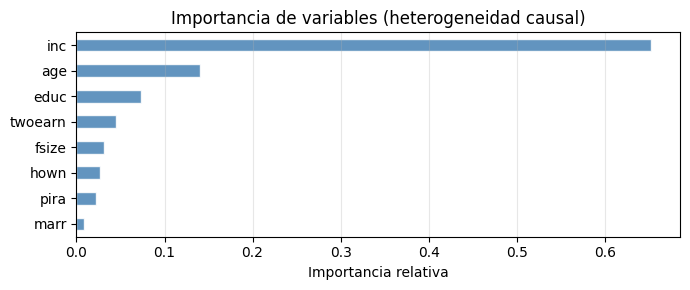

In [ ]:
importancias = pd.Series(cf.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(7, 3))
importancias.plot(kind='barh', ax=ax, color='steelblue', alpha=0.85, edgecolor='white')
ax.set_title('Importancia de variables (heterogeneidad causal)')
ax.set_xlabel('Importancia relativa')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

A diferencia del Random Forest predictivo, los cortes del Causal Forest maximizan la varianza del efecto estimado entre ramas — no la reducción de impureza de Y. Esta métrica mide cuánto contribuye cada variable a la **heterogeneidad causal**, no a la predicción del outcome.

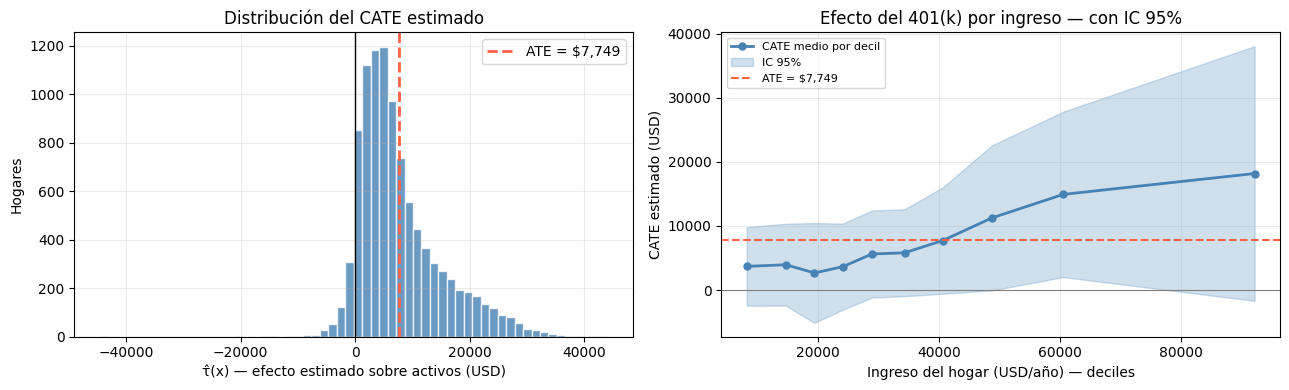

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel izquierdo: distribución del CATE estimado
axes[0].hist(cate, bins=60, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(ate_cf, color='tomato', linewidth=2, linestyle='--',
                label=f'ATE = ${ate_cf:,.0f}')
axes[0].axvline(0, color='k', linewidth=1)
axes[0].set_xlabel('τ̂(x) — efecto estimado sobre activos (USD)')
axes[0].set_ylabel('Hogares')
axes[0].set_title('Distribución del CATE estimado')
axes[0].legend(); axes[0].grid(True, alpha=0.25)

# Panel derecho: CATE por decil de ingreso con banda de IC 95%
# Un scatter de 9.900 puntos con error bars es ilegible — agrupamos en deciles
n_bins = 10
idx_sorted = np.argsort(X['inc'].values)
bins = np.array_split(idx_sorted, n_bins)

inc_med    = [X['inc'].values[b].mean()  for b in bins]
cate_med   = [cate[b].mean()             for b in bins]
cate_lo    = [cate_lb[b].mean()          for b in bins]
cate_hi    = [cate_ub[b].mean()          for b in bins]

axes[1].plot(inc_med, cate_med, color='steelblue', linewidth=2, marker='o', markersize=5,
             label='CATE medio por decil')
axes[1].fill_between(inc_med, cate_lo, cate_hi, alpha=0.25, color='steelblue', label='IC 95%')
axes[1].axhline(ate_cf, color='tomato', linewidth=1.5, linestyle='--',
                label=f'ATE = ${ate_cf:,.0f}')
axes[1].axhline(0, color='gray', linewidth=0.8)
axes[1].set_xlabel('Ingreso del hogar (USD/año) — deciles')
axes[1].set_ylabel('CATE estimado (USD)')
axes[1].set_title('Efecto del 401(k) por ingreso — con IC 95%')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

La distribución del CATE muestra si el efecto está concentrado en pocos hogares o es disperso — condición necesaria para que focalizar valga la pena. Ingreso ya aparece en el panel derecho; los scatters muestran edad y educación porque son las dos variables con mayor importancia causal en el gráfico anterior.

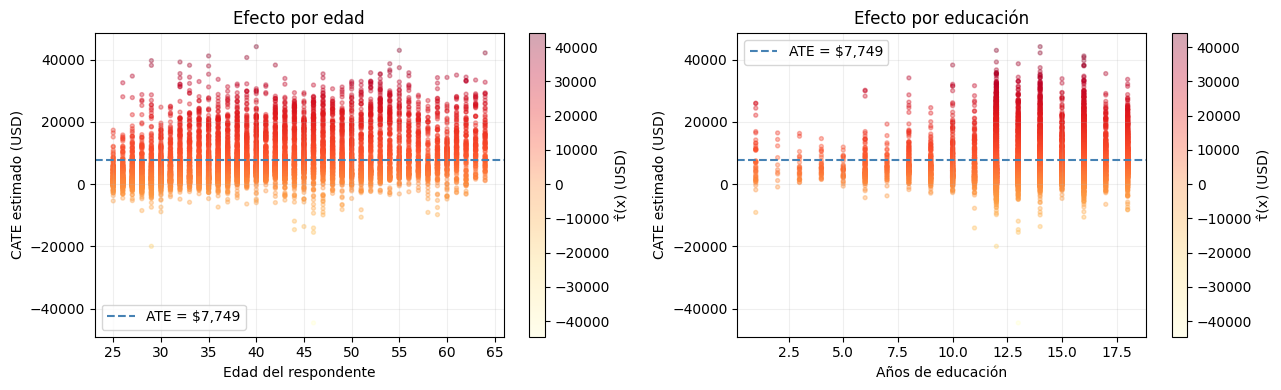

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel izquierdo: CATE vs edad
sc1 = axes[0].scatter(X['age'], cate, c=cate, cmap='YlOrRd', alpha=0.35, s=8)
plt.colorbar(sc1, ax=axes[0], label='τ̂(x) (USD)')
axes[0].axhline(ate_cf, color='steelblue', linewidth=1.5, linestyle='--',
                label=f'ATE = ${ate_cf:,.0f}')
axes[0].set_xlabel('Edad del respondente'); axes[0].set_ylabel('CATE estimado (USD)')
axes[0].set_title('Efecto por edad'); axes[0].legend(); axes[0].grid(True, alpha=0.2)

# Panel derecho: CATE vs educación (años)
sc2 = axes[1].scatter(X['educ'], cate, c=cate, cmap='YlOrRd', alpha=0.35, s=8)
plt.colorbar(sc2, ax=axes[1], label='τ̂(x) (USD)')
axes[1].axhline(ate_cf, color='steelblue', linewidth=1.5, linestyle='--',
                label=f'ATE = ${ate_cf:,.0f}')
axes[1].set_xlabel('Años de educación'); axes[1].set_ylabel('CATE estimado (USD)')
axes[1].set_title('Efecto por educación'); axes[1].legend(); axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
blp = ldml.coef__inference().summary_frame(feature_names=feature_cols)
display(blp)

,point_estimate,stderr,zstat,pvalue,ci_lower,ci_upper
X,,,,,,
age,192.518,78.849,2.442,0.015,37.977,347.059
inc,0.221,0.066,3.342,0.001,0.091,0.350
fsize,-560.111,513.258,-1.091,0.275,-1566.078,445.856
educ,-531.552,324.253,-1.639,0.101,-1167.075,103.972
pira,-2986.500,2185.866,-1.366,0.172,-7270.718,1297.719
hown,2886.990,1387.748,2.080,0.037,167.054,5606.926
marr,-242.183,2493.996,-0.097,0.923,-5130.324,4645.959
twoearn,-571.203,2466.459,-0.232,0.817,-5405.373,4262.968


**Best Linear Predictor (BLP):** proyecta el CATE sobre X linealmente — los coeficientes muestran qué variables se asocian con un efecto más alto o más bajo, con IC válidos que evitan el problema de tratar los τ̂(x) estimados como si fueran observados.

---

## **Paso 7 — Política de focalización**

Supón que el gobierno puede subsidiar la adopción de planes 401(k) solo a un subconjunto de empresas. Con el CATE podemos ordenar los hogares de mayor a menor beneficio estimado y responder: si cubrimos solo al $k$% más responsivo, ¿cuánto más ahorro generamos por dólar gastado que con una política universal?

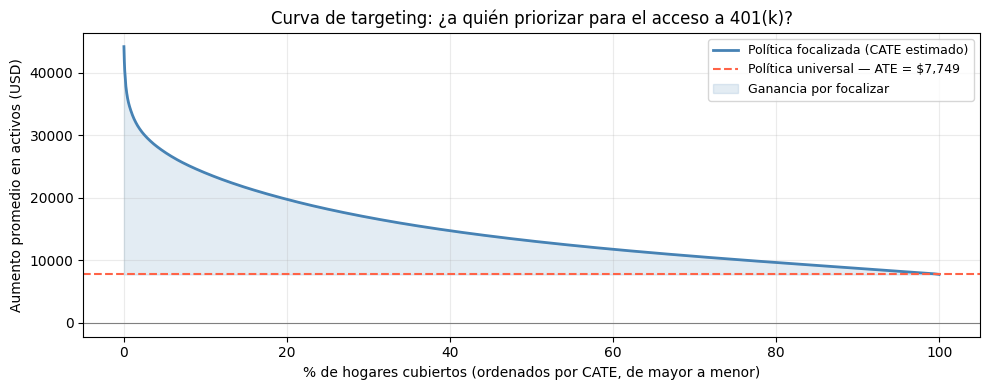

Efecto promedio — top 30% de hogares:  $    16,857
Efecto promedio — política universal:   $     7,749
Ganancia por focalizar el top 30%:      $     9,108  (+118%)
AUUC (ganancia sobre asignación aleatoria): $7,143 USD


In [ ]:
# 1. Ordenar hogares de mayor a menor CATE estimado (los que más se benefician, primero)
df_res    = pd.DataFrame({'cate': cate})
df_sorted = df_res.sort_values('cate', ascending=False).reset_index(drop=True)

# 2. Efecto acumulado promedio al cubrir los primeros k hogares
efecto_est = df_sorted['cate'].expanding().mean()
pct_pop    = (df_sorted.index + 1) / len(df_sorted) * 100

# 3. Gráfico
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(pct_pop, efecto_est, color='steelblue', linewidth=2, label='Política focalizada (CATE estimado)')
ax.axhline(ate_cf, color='tomato', linewidth=1.5, linestyle='--',
           label=f'Política universal — ATE = ${ate_cf:,.0f}')
ax.axhline(0, color='gray', linewidth=0.8)
ax.fill_between(pct_pop, ate_cf, efecto_est,
                where=(efecto_est > ate_cf), alpha=0.15, color='steelblue',
                label='Ganancia por focalizar')
ax.set_xlabel('% de hogares cubiertos (ordenados por CATE, de mayor a menor)')
ax.set_ylabel('Aumento promedio en activos (USD)')
ax.set_title('Curva de targeting: ¿a quién priorizar para el acceso a 401(k)?')
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# 4. Punto de política concreto
top30_idx    = int(0.30 * len(df_sorted))
efecto_top30 = df_sorted['cate'].iloc[:top30_idx].mean()
print(f'Efecto promedio — top 30% de hogares:  ${efecto_top30:>10,.0f}')
print(f'Efecto promedio — política universal:   ${ate_cf:>10,.0f}')
print(f'Ganancia por focalizar el top 30%:      ${efecto_top30 - ate_cf:>10,.0f}  '
      f'(+{(efecto_top30/ate_cf - 1)*100:.0f}%)')

# 5. AUUC — np.trapezoid reemplaza a np.trapz en NumPy 2.0+
auuc = np.trapezoid(efecto_est.values - ate_cf, pct_pop.values / 100)
print(f'AUUC (ganancia sobre asignación aleatoria): ${auuc:,.0f} USD')

La curva cae porque al ampliar la cobertura se van incluyendo hogares con menor CATE — converge al ATE cuando se cubre al 100%. La brecha azul entre la curva y la línea roja es la ganancia de focalizar: cuánto ahorro adicional se genera por dólar gastado respecto a una política universal.

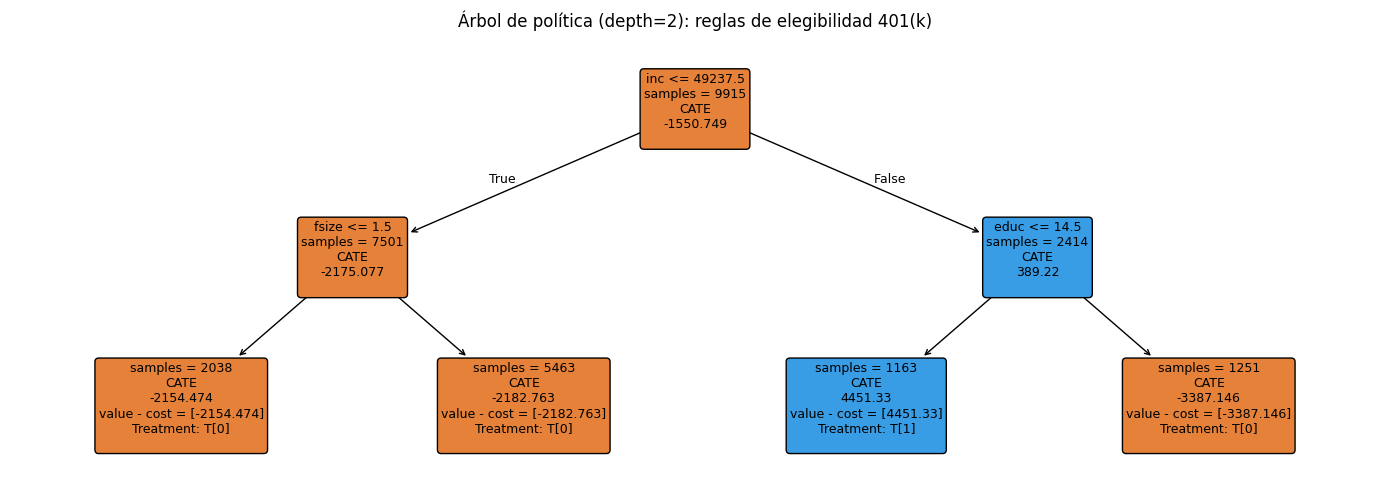

In [ ]:
from econml.cate_interpreter import SingleTreePolicyInterpreter

interp = SingleTreePolicyInterpreter(risk_level=0.05, max_depth=2, min_samples_leaf=50)
interp.interpret(cf, X)

fig, ax = plt.subplots(figsize=(14, 5))
interp.plot(feature_names=feature_cols, fontsize=9, ax=ax)
ax.set_title('Árbol de política (depth=2): reglas de elegibilidad 401(k)')
plt.tight_layout()
plt.show()

Solo **1 de 4 grupos** recibe tratamiento ($T=1$):

- **Ingreso $\leq$ \$49k** → no tratar  
  CATE negativo en ambas ramas.

- **Ingreso $>$ \$49k + educación $\leq$ 15 años** → **tratar**  
  CATE = **+\$4,271**.  
  Corresponde a trabajadores calificados sin título universitario.

- **Ingreso $>$ \$49k + educación $\geq$ 16 años** → no tratar  
  Ya ahorran por otros mecanismos, como IRA u otros instrumentos.

---

### **¿Qué aprendimos?**

- **OLS** estima un ATE de varios miles de dólares (ver Paso 2). **Causal Forest** agrega: el efecto es mayor para hogares de mayor ingreso y edad — esa heterogeneidad es lo que hace rentable focalizar la política.
- **DML** (Local Centering) quita la confusión de que los hogares de mayor ingreso tienden tanto a trabajar en empresas con 401(k) como a ahorrar más por otras razones. Sin DML, el CATE mezclaría causalidad con selección.
- **Ignorabilidad condicional** es el supuesto que hace el trabajo causal — no un RCT. Eso significa que el resultado depende de qué tan bien X captura las diferencias entre empleadores. Es el supuesto que hay que defender con argumentos sustantivos, no un dato.
- **Honesty** garantiza que los IC sobre τ(x) son estadísticamente válidos — se puede reportar un intervalo real, no solo un punto.
- La **curva de targeting** traduce el CATE en decisión de política: focalizar el subsidio en el top 30% de hogares más responsivos genera significativamente más ahorro por dólar gastado que una política universal.
- Usamos los **mismos datos** que los autores del método (Athey et al., 2019) — esto es lo que ven los investigadores que trabajan con causal inference en la práctica.

---

##### *Referencias*

- Athey, S., Tibshirani, J., & Wager, S. (2019). Generalized random forests. *Annals of Statistics, 47*(2), 1148–1178.
- Wager, S., & Athey, S. (2018). Estimation and inference of heterogeneous treatment effects using random forests. *JASA, 113*(523), 1228–1242.
- Chernozhukov, V., et al. (2018). Double/debiased machine learning. *The Econometrics Journal, 21*(1), C1–C68.
- Robinson, P. M. (1988). Root-n-consistent semiparametric regression. *Econometrica, 56*(4), 931–954.
- Poterba, J. M., Venti, S. F., & Wise, D. A. (1995). Do 401(k) contributions crowd out other personal saving? *Journal of Public Economics, 58*(1), 1–32.
- Microsoft Research — `EconML`: `CausalForestDML`, `SingleTreePolicyInterpreter`.